# CLUTRR Kinship Gold Graphs — Demo

**Dataset:** *CLUTRR kinship gold graphs: two hop-stratified slices with absent-relation pairs*

This notebook is a small, runnable tour of the **CLUTRR kinship gold-graph corpus** built by
`data.py`. CLUTRR (Sinha et al., EMNLP 2019, [arXiv:1908.06177](https://arxiv.org/abs/1908.06177))
is a diagnostic benchmark of semi-synthetic family stories. `data.py` standardizes it into the aii
`exp_sel_data_out` schema — **one row per story** — so that a single corpus delivers the four
numbers the closure-certificate umbrella names:

1. **atomic-fact extraction** precision/recall — the directly-stated kinship facts = the proof chain;
2. **multi-hop deduction** accuracy vs. chain length — the held-out *query* edge, deduced by
   composing ≥2 atomic facts;
3. a **human-auditable trace-graph** — the backward-chaining gold proof; and
4. a **hallucination-rate** reduction demo on **absent-relation** pairs — entity pairs in different
   connected components ⇒ provably *no* kinship path ⇒ an honest "no-relation".

Each row carries `input` = the de-bracketed natural-language story, `output` =
`json.dumps(gold_graph)` (nodes + typed atomic edges + structural noise edges + the held-out query
edge + absent-relation pairs), and flat `metadata_*` fields.

This demo loads a **curated 60-story subset of the `clutrr_disc` slice** (the richest single slice:
typed proof chains *and* structural noise edges *and* absent-relation pairs), reuses the original
`data.py` parsing/analysis helpers **verbatim**, and visualizes a trace-graph.

> The full corpus (26,676 stories) is rebuilt with `uv run data.py`, which downloads the CLUTRR
> CSVs + the `facebookresearch/clutrr` composition YAMLs. This demo needs **no downloads** — the
> already-built subset (including the finite kinship composition table) is loaded from a small JSON.

In [1]:
%%capture
# --- Install dependencies (Colab-safe) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# networkx, pandas, matplotlib (and numpy) are all pre-installed on Colab.
# On Colab: skip them (use Colab's versions). Locally: install at Colab's exact
# versions so the local env mirrors Colab.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'networkx==3.6.1')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (from data.py, trimmed to what the demo exercises) + matplotlib ---
import ast
import json
import re
from collections import Counter, defaultdict
from statistics import mean, median

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [3]:
# --- Data loading: GitHub URL (after deployment) with local fallback (now / offline) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-2/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
metadata = data["metadata"]
dataset  = data["datasets"][0]
examples = dataset["examples"]
print(f"loaded dataset : {dataset['dataset']}  |  {len(examples)} stories")
print(f"corpus name    : {metadata['name']}")
print(f"schema         : {metadata['schema']}")

loaded dataset : clutrr_disc  |  60 stories
corpus name    : CLUTRR kinship gold graphs
schema         : exp_sel_data_out (input=story string, output=json.dumps(gold_graph), structured per-row data under metadata_* keys).


## Config

All tunable demo parameters live here. They start at the **minimum** that produces output and can
be scaled up freely — every step in this notebook is cheap (pure-Python graph/tally ops on a tiny
subset). `N_EXAMPLES` is the demo analog of `data.py`'s `--limit` (rows processed).

In [5]:
# ---- tunable demo parameters ----
N_EXAMPLES          = 60   # stories to run the descriptive-count / certification analysis over
                           # (full curated subset = len(examples) = 60; data.py analog: --limit).
                           # Set to e.g. 2 for a fast minimal pass; 60 = the whole curated subset.
EXAMPLE_TO_INSPECT  = 1    # index of the story to walk through field-by-field
TRACE_GRAPH_EXAMPLE = 1    # index of the story to draw as a trace-graph
ABSENT_PAIR_CAP     = 20   # cap on absent-relation pairs per story (data.py default = 20)

N_EXAMPLES = min(N_EXAMPLES, len(examples))
subset = examples[:N_EXAMPLES]
print(f"analyzing {len(subset)} / {len(examples)} stories")

analyzing 60 / 60 stories


## 1. The finite kinship composition table

`data.py` reads the composition rules verbatim from `facebookresearch/clutrr`
(`rules_store.yaml` / `relations_store.yaml`) and ships them **once** in the top-level metadata.
This is the symbolic background knowledge a downstream reasoner (e.g. a Prolog interpreter) would
use to *deduce* the held-out query relation from the atomic facts. It is a **finite composition
table over 11 kinship relation TYPES**, not a full relation algebra.

* `relation_types` — the 11 abstract types (+ symmetry / inverse flags),
* `surface_forms` — (type × gender) → the surface kinship word,
* `surface_reverse` — surface word → `[type, gender]`,
* `composition_rules` — `rules[t1][t2] = t3` (compose A‑t1‑B, B‑t2‑C ⇒ A‑t3‑C),
* `label_map` — the canonical int ↔ text label order (0..20).

In [6]:
ct = metadata["composition_table"]
print("relation types:", list(ct["relation_types"]))
print("\nsemantics:", ct["semantics"])

# (type x gender) -> surface word
surf = pd.DataFrame(ct["surface_forms"]).T
surf.index.name = "relation_type"
print("\n(type x gender) -> surface form:")
display(surf)

# composition rules rules[t1][t2] = t3, as a readable matrix
comp = pd.DataFrame(ct["composition_rules"]).T
comp.index.name = "t1 \\ t2"
print("\ncomposition rules  rules[t1][t2] = t3  (NaN = no rule in the finite table):")
display(comp)

relation types: ['child', 'inv-child', 'SO', 'sibling', 'grand', 'inv-grand', 'in-law', 'inv-in-law', 'sibling-in-law', 'un', 'inv-un']

semantics: Triple (h, r, t) reads 't is h's r'. Composition: A t1 B, B t2 C => A t3 C, where rules[t1][t2]=t3 and the surface form of t3 uses the gender of C.

(type x gender) -> surface form:


,male,female
relation_type,,
child,son,daughter
inv-child,father,mother
SO,husband,wife
sibling,brother,sister
grand,grandson,granddaughter
inv-grand,grandfather,grandmother
in-law,son-in-law,daughter-in-law
inv-in-law,father-in-law,mother-in-law
sibling-in-law,brother-in-law,sister-in-law



composition rules  rules[t1][t2] = t3  (NaN = no rule in the finite table):


,child,SO,sibling,inv-un,inv-grand,inv-child,grand
t1 \ t2,,,,,,,
child,grand,in-law,child,sibling,inv-child,NaN,NaN
inv-child,sibling,NaN,inv-un,NaN,NaN,inv-grand,NaN
SO,child,NaN,NaN,NaN,NaN,inv-in-law,grand
sibling,un,NaN,sibling,NaN,inv-grand,inv-child,NaN
grand,NaN,NaN,grand,NaN,NaN,NaN,NaN


## 2. The `data.py` parsing & analysis helpers (verbatim)

These are copied **unchanged** from `data.py`. `bracket_parse` strips the `[Name]` markers from a
CLUTRR story and records the character spans of every mention; `absent_pairs_from_components` finds
entity pairs in different connected components (⇒ provably no kinship path); and
`descriptive_counts` / `hist` / `length_stats` are the pure tally functions that summarize a slice.
(`parse_proof` and `build_composition_table` run only at *build* time on the raw CSV / YAML inputs,
so they are described above rather than re-run here.)

In [7]:
# ===== verbatim from data.py =====

def bracket_parse(story: str):
    """Remove '['/']' markers; return (input_text, mention_spans name->[[s,e],...])."""
    out, spans, i, n = [], defaultdict(list), 0, len(story)
    cur = 0  # running length of input_text
    while i < n:
        c = story[i]
        if c == "[":
            j = story.index("]", i)
            name = story[i + 1:j]
            spans[name].append([cur, cur + len(name)])
            out.append(name)
            cur += len(name)
            i = j + 1
        else:
            out.append(c)
            cur += 1
            i += 1
    return "".join(out), {k: v for k, v in spans.items()}


def absent_pairs_from_components(node_ids, story_edges, node2name, query_nodes, cap=20):
    """Pairs of entities in DIFFERENT connected components => structural no-relation."""
    g = nx.Graph()
    g.add_nodes_from(node_ids)
    g.add_edges_from([tuple(e) for e in story_edges])
    comps = [sorted(c) for c in nx.connected_components(g)]
    qset = set(query_nodes)
    main = next((c for c in comps if qset & set(c)), comps[0] if comps else [])
    main_set = set(main)
    pairs = []
    # prioritise pairs that touch the main (query) component
    for m in sorted(main_set):
        for o in sorted(node_ids - main_set):
            a, b = sorted((m, o))
            pairs.append((a, b))
    # then remaining cross-component pairs (non-main x non-main, different comp)
    comp_of = {}
    for ci, c in enumerate(comps):
        for nd in c:
            comp_of[nd] = ci
    extra = []
    non_main = sorted(node_ids - main_set)
    for ii in range(len(non_main)):
        for jj in range(ii + 1, len(non_main)):
            a, b = non_main[ii], non_main[jj]
            if comp_of[a] != comp_of[b]:
                extra.append(tuple(sorted((a, b))))
    seen = set(pairs)
    for p in extra:
        if p not in seen:
            pairs.append(p)
            seen.add(p)
    pairs = pairs[:cap]
    out = [
        {"source": a, "target": b,
         "source_name": node2name[a], "target_name": node2name[b],
         "gold": "no-relation"}
        for a, b in pairs
    ]
    return out, comps


def hist(values):
    return dict(sorted(Counter(values).items()))


def length_stats(vals):
    vs = sorted(vals)
    if not vs:
        return {}
    return {
        "min": vs[0], "max": vs[-1],
        "mean": round(mean(vs), 1), "median": int(median(vs)),
        "p90": vs[int(0.9 * (len(vs) - 1))],
        "n_ge_2000_chars": sum(v >= 2000 for v in vs),
        "n_ge_3000_chars": sum(v >= 3000 for v in vs),
    }


def descriptive_counts(name, examples):
    char_lens = [e["metadata_story_char_len"] for e in examples]
    n_with_absent = sum(e["metadata_absent_pair_count"] > 0 for e in examples)
    return {
        "n_stories": len(examples),
        "n_entities_total": sum(e["metadata_num_entities"] for e in examples),
        "n_atomic_edges_total": sum(e["metadata_num_atomic_edges"] for e in examples),
        "n_noise_edges_total": sum(e["metadata_num_noise_edges"] for e in examples),
        "fold_counts": hist(e["metadata_fold"] for e in examples),
        "hop_count_distribution": hist(e["metadata_hop_count"] for e in examples),
        "relation_label_distribution": hist(e["metadata_query"]["relation"] for e in examples),
        "noise_type_distribution": hist(e["metadata_noise_type"] for e in examples),
        "component_count_distribution": hist(e["metadata_num_components"] for e in examples),
        "n_stories_with_absent_pairs": n_with_absent,
        "total_absent_pairs": sum(e["metadata_absent_pair_count"] for e in examples),
        "story_char_length": length_stats(char_lens),
    }

print("helpers loaded:", [f.__name__ for f in
      (bracket_parse, absent_pairs_from_components, hist, length_stats, descriptive_counts)])

helpers loaded: ['bracket_parse', 'absent_pairs_from_components', 'hist', 'length_stats', 'descriptive_counts']


## 3. One story, field by field

We take a single `clutrr_disc` story and unpack it: the de-bracketed `input` text, the parsed
`gold_graph` (`output`), the typed atomic facts (the proof chain), the held-out **query** edge
(what a model must *deduce*), the structural **noise** edges, and the **absent-relation** pairs.
We also re-run `bracket_parse` on the bracketed `metadata_clean_story` (the de-noised proof-chain
text) to show how `data.py` strips the `[Name]` markers and records each mention's character-span,
and we verify every recorded span is the exact mention substring — `data.py`'s span-consistency
invariant (0 mismatches corpus-wide).

In [8]:
ex = examples[EXAMPLE_TO_INSPECT]
gold = json.loads(ex["output"])
id2name = {n["entity_id"]: n["surface"] for n in gold["nodes"]}

print("=" * 80)
print(f"doc_id     : {ex['metadata_doc_id']}")
print(f"fold/noise : {ex['metadata_fold']} / {ex['metadata_noise_type']}   "
      f"(task {ex['metadata_task_name']}, {ex['metadata_hop_count']} hops)")
print("=" * 80)
print("\nINPUT STORY (de-bracketed):\n ", ex["input"])

print("\nENTITY NODES:")
for n in gold["nodes"]:
    print(f"  [{n['entity_id']}] {n['surface']:<10} ({n['gender']})  spans={n['mention_spans']}")

print("\nATOMIC FACTS (the directly-stated proof chain; reads 'target is source's relation'):")
for e in gold["edges"]:
    print(f"  {id2name[e['source']]:<10} --{e['kinship_relation']} ({e['relation_type']})--> "
          f"{id2name[e['target']]}")

q = gold["query_edge"]
print(f"\nHELD-OUT QUERY (deduce, NOT stated): what is {id2name[q['source']]}'s "
      f"relation to {id2name[q['target']]}?")
print(f"  gold answer = '{q['kinship_relation']}'  (type {q['relation_type']}, "
      f"int {q['target_int']}, {q['hop_count']} hops)")

print("\nNOISE EDGES (stated but untyped by CLUTRR; structural only):")
for e in gold["noise_edges"]:
    print(f"  {e['source_name']} -- ? --> {e['target_name']}")

print(f"\nABSENT-RELATION PAIRS ({len(gold['absent_relation_pairs'])}; "
      f"different components => no kinship path):")
for p in gold["absent_relation_pairs"][:8]:
    print(f"  {p['source_name']} <-/-> {p['target_name']}  => '{p['gold']}'")

# data.py runs bracket_parse on the bracketed story to strip [Name] markers and record spans.
# clean_story is the de-noised proof-chain text; de-bracket it and confirm every recorded span
# is the exact mention substring (data.py's span-consistency invariant => 0 mismatches corpus-wide).
clean_text, spans = bracket_parse(ex["metadata_clean_story"])
print("\nbracketed clean_story :", ex["metadata_clean_story"])
print("de-bracketed          :", clean_text)
span_ok = all(clean_text[s:e] == nm for nm, sl in spans.items() for s, e in sl)
print("all recorded spans are exact mention substrings :", span_ok)

doc_id     : 00252220-8171-4978-8889-c5dbf56f4787
fold/noise : train / disconnected   (task task_4.3, 3 hops)

INPUT STORY (de-bracketed):
  Maida loves her grandson, Max, and he loves her too. Maura got accepted into her dream college. Her father Norman could not be any prouder. Jerry loves his son-in-law Willie like his own son. Willie loves Jerry too. Max's dad Norman is the CEO of the company.

ENTITY NODES:
  [0] Maida      (female)  spans=[[0, 5]]
  [1] Max        (male)  spans=[[26, 29], [216, 219]]
  [2] Norman     (male)  spans=[[107, 113], [226, 232]]
  [3] Maura      (female)  spans=[[53, 58]]
  [4] Jerry      (male)  spans=[[140, 145], [205, 210]]
  [5] Willie     (male)  spans=[[167, 173], [192, 198]]

ATOMIC FACTS (the directly-stated proof chain; reads 'target is source's relation'):
  Maida      --grandson (grand)--> Max
  Max        --father (inv-child)--> Norman
  Norman     --daughter (child)--> Maura

HELD-OUT QUERY (deduce, NOT stated): what is Maida's relation to 

## 4. Re-deriving the absent-relation pairs (reusing `data.py` verbatim)

The absent pairs are purely **structural**: build the story graph from *all* stated edges (atomic
proof chain + untyped noise edges), find the connected components, and emit every cross-component
pair touching the query component. Here we feed the loaded graph back into the original
`absent_pairs_from_components` and confirm it reproduces the shipped pairs.

In [9]:
gold = json.loads(examples[EXAMPLE_TO_INSPECT]["output"])
id2name = {n["entity_id"]: n["surface"] for n in gold["nodes"]}

# all stated edges = typed atomic (proof chain) + untyped structural noise edges
story_edges = [(e["source"], e["target"]) for e in gold["edges"]] \
            + [(e["source"], e["target"]) for e in gold["noise_edges"]]
node_ids = set(id2name)
q = gold["query_edge"]

rederived, comps = absent_pairs_from_components(
    node_ids, story_edges, id2name, (q["source"], q["target"]), cap=ABSENT_PAIR_CAP)

print(f"connected components : {len(comps)}  ->  {comps}")
print(f"re-derived {len(rederived)} absent pairs;  shipped {len(gold['absent_relation_pairs'])}")
got     = {(p['source'], p['target']) for p in rederived}
shipped = {(p['source'], p['target']) for p in gold['absent_relation_pairs']}
print("re-derived set == shipped set :", got == shipped)

connected components : 2  ->  [[0, 1, 2, 3], [4, 5]]
re-derived 8 absent pairs;  shipped 8
re-derived set == shipped set : True


## 5. Certifying the gold proof against the composition table

The shipped `metadata_gold_proof` is CLUTRR's backward-chaining derivation: each step expands a goal
`(h, r, t)` into two sub-facts `(h, r1, m)` and `(m, r2, t)`. Every such step is a **single
composition**, so it must satisfy `rules[type(r1)][type(r2)] = type(r)`. We check every proof step of
every analyzed story against the shipped table — this is exactly the symbolic certificate a
neuro-symbolic pipeline would emit for each reasoning hop.

In [10]:
rules           = ct["composition_rules"]
surface_reverse = ct["surface_reverse"]   # surface word -> [type, gender]

def certify_step(goal, sub1, sub2):
    """A proof step (h,r,t) <- (h,r1,m),(m,r2,t) is valid iff rules[t(r1)][t(r2)] = t(r)."""
    t_r1 = surface_reverse.get(sub1[1], [None])[0]
    t_r2 = surface_reverse.get(sub2[1], [None])[0]
    t_r  = surface_reverse.get(goal[1], [None])[0]
    return rules.get(t_r1, {}).get(t_r2) == t_r

n_ok = n_steps = shown = 0
for ex in subset:
    for step in ex["metadata_gold_proof"]:
        if len(step["subgoals"]) != 2:
            continue
        s1, s2 = step["subgoals"]
        ok = certify_step(step["goal"], s1, s2)
        n_steps += 1
        n_ok += int(ok)
        if shown < 6:
            g = step["goal"]
            print(f"  {g[0]} -{g[1]}-> {g[2]}   <=   "
                  f"({s1[0]} -{s1[1]}-> {s1[2]}) o ({s2[0]} -{s2[1]}-> {s2[2]})   "
                  f"{'CERTIFIED' if ok else 'NOT-IN-TABLE'}")
            shown += 1
print(f"\ncomposition table certifies {n_ok}/{n_steps} gold proof steps "
      f"across {len(subset)} stories")

  Clara -grandfather-> Cruz   <=   (Clara -father-> Robert) o (Robert -father-> Cruz)   CERTIFIED
  Maida -granddaughter-> Maura   <=   (Maida -grandson-> Max) o (Max -sister-> Maura)   CERTIFIED
  Max -sister-> Maura   <=   (Max -father-> Norman) o (Norman -daughter-> Maura)   CERTIFIED
  Cruz -son-> Robert   <=   (Cruz -son-> Timothy) o (Timothy -brother-> Robert)   CERTIFIED
  Roberta -grandfather-> Stephen   <=   (Roberta -brother-> Johnny) o (Johnny -grandfather-> Stephen)   CERTIFIED
  Roberta -brother-> Johnny   <=   (Roberta -brother-> Justin) o (Justin -brother-> Johnny)   CERTIFIED

composition table certifies 100/100 gold proof steps across 60 stories


## 6. Descriptive counts (the `data.py` summary, run on the subset)

`descriptive_counts` is run **verbatim** on the loaded subset. The same function produced the
corpus-level tallies shipped in the metadata, which we print alongside for reference (the demo
subset is 60 hand-picked `clutrr_disc` stories, so its distribution differs from the full corpus).

In [11]:
counts = descriptive_counts(dataset["dataset"], subset)

print(f"=== descriptive_counts over {len(subset)} demo stories ===")
for k, v in counts.items():
    print(f"{k:32}: {v}")

print("\n=== shipped full-corpus counts (clutrr_disc, 10,545 stories) ===")
full = metadata["descriptive_counts"]["per_corpus"]["clutrr_disc"]
for k in ("n_stories", "hop_count_distribution", "noise_type_distribution",
          "n_stories_with_absent_pairs", "total_absent_pairs", "story_char_length"):
    print(f"{k:32}: {full[k]}")

=== descriptive_counts over 60 demo stories ===
n_stories                       : 60
n_entities_total                : 313
n_atomic_edges_total            : 160
n_noise_edges_total             : 60
fold_counts                     : {'test': 20, 'train': 40}
hop_count_distribution          : {2: 20, 3: 40}
relation_label_distribution     : {'aunt': 2, 'brother': 6, 'daughter': 2, 'father': 13, 'father-in-law': 1, 'granddaughter': 2, 'grandfather': 5, 'grandmother': 3, 'grandson': 8, 'mother': 8, 'mother-in-law': 1, 'nephew': 2, 'niece': 1, 'sister': 2, 'son': 3, 'son-in-law': 1}
noise_type_distribution         : {'disconnected': 40, 'irrelevant': 6, 'none': 7, 'supporting': 7}
component_count_distribution    : {1: 20, 2: 40}
n_stories_with_absent_pairs     : 40
total_absent_pairs              : 280
story_char_length               : {'min': 83, 'max': 420, 'mean': 223.7, 'median': 220, 'p90': 288, 'n_ge_2000_chars': 0, 'n_ge_3000_chars': 0}

=== shipped full-corpus counts (clutrr_disc, 1

## 7. Visualizations

**(a) Trace-graph** of one story — the human-auditable proof graph: typed atomic edges (solid blue,
labeled), the held-out query edge (dashed red, what must be *deduced*), and absent-relation pairs
(dotted grey, "no path"). **(b)/(c) Distribution bar charts** over the demo subset (hop count and
query relation).

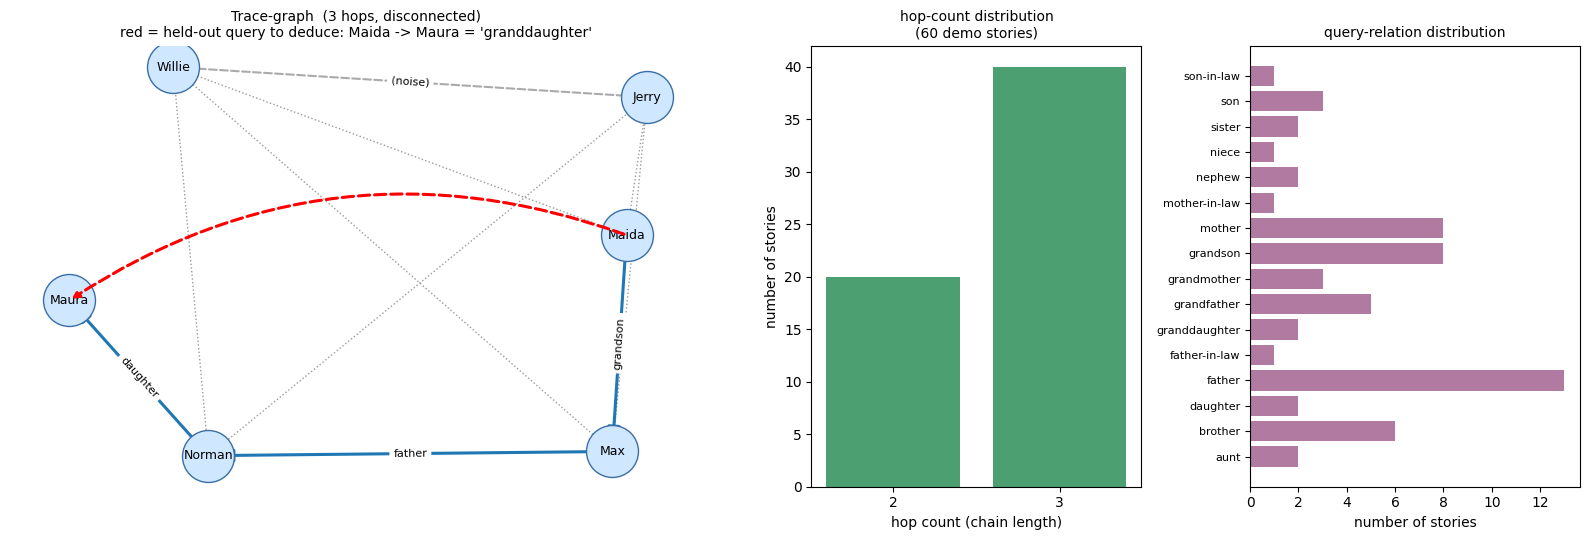

saved figure -> demo_trace_and_dist.png


In [12]:
# ---------- (a) trace-graph of one story ----------
gex = examples[TRACE_GRAPH_EXAMPLE]
gold = json.loads(gex["output"])
id2name = {n["entity_id"]: n["surface"] for n in gold["nodes"]}

G = nx.DiGraph()
for nm in id2name.values():
    G.add_node(nm)
for e in gold["edges"]:
    G.add_edge(id2name[e["source"]], id2name[e["target"]], label=e["kinship_relation"])
for e in gold["noise_edges"]:
    G.add_edge(e["source_name"], e["target_name"], label="(noise)")

q = gold["query_edge"]
qh, qt = id2name[q["source"]], id2name[q["target"]]

fig = plt.figure(figsize=(16, 5.5))
gs = fig.add_gridspec(1, 3, width_ratios=[2.1, 1, 1])
ax = fig.add_subplot(gs[0, 0])

pos = nx.spring_layout(G, seed=42, k=1.3)
atomic = [(id2name[e["source"]], id2name[e["target"]]) for e in gold["edges"]]
noise  = [(e["source_name"], e["target_name"]) for e in gold["noise_edges"]]
nx.draw_networkx_nodes(G, pos, node_color="#cfe8ff", node_size=1400,
                       edgecolors="#3b6ea5", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=atomic, edge_color="#1f77b4", width=2.2,
                       arrowsize=18, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=noise, edge_color="#aaaaaa", width=1.5,
                       style="dashed", arrowsize=12, ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"),
                             font_size=8, ax=ax)
# held-out query edge (red dashed) + absent-relation pairs (grey dotted)
ax.annotate("", xy=pos[qt], xytext=pos[qh],
            arrowprops=dict(arrowstyle="-|>", color="red", lw=2.2, ls="--",
                            connectionstyle="arc3,rad=0.25"))
for p in gold["absent_relation_pairs"][:6]:
    a, b = p["source_name"], p["target_name"]
    if a in pos and b in pos:
        ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]],
                color="#999999", ls=":", lw=1.0, zorder=0)
ax.set_title(f"Trace-graph  ({gex['metadata_hop_count']} hops, {gex['metadata_noise_type']})\n"
             f"red = held-out query to deduce: {qh} -> {qt} = '{q['kinship_relation']}'",
             fontsize=10)
ax.axis("off")

# ---------- (b) hop-count distribution over the subset ----------
ax2 = fig.add_subplot(gs[0, 1])
hop_hist = hist(e["metadata_hop_count"] for e in subset)
ax2.bar([str(k) for k in hop_hist], list(hop_hist.values()), color="#4c9f70")
ax2.set_xlabel("hop count (chain length)")
ax2.set_ylabel("number of stories")
ax2.set_title(f"hop-count distribution\n({len(subset)} demo stories)", fontsize=10)

# ---------- (c) query-relation distribution over the subset ----------
ax3 = fig.add_subplot(gs[0, 2])
rel_hist = hist(e["metadata_query"]["relation"] for e in subset)
ax3.barh(list(rel_hist), list(rel_hist.values()), color="#b07aa1")
ax3.set_xlabel("number of stories")
ax3.set_title("query-relation distribution", fontsize=10)
ax3.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig("demo_trace_and_dist.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved figure -> demo_trace_and_dist.png")

## 8. Per-story summary table

A compact `pandas` view of the analyzed subset — one row per story, with the structural descriptors
that downstream experiments (atomic-extraction P/R, multi-hop accuracy, hallucination on absent
pairs) consume.

In [13]:
rows = []
for i, ex in enumerate(subset):
    rows.append({
        "i": i,
        "doc_id": ex["metadata_doc_id"][:8],
        "hops": ex["metadata_hop_count"],
        "noise": ex["metadata_noise_type"],
        "n_ent": ex["metadata_num_entities"],
        "n_atomic": ex["metadata_num_atomic_edges"],
        "n_noise": ex["metadata_num_noise_edges"],
        "n_comp": ex["metadata_num_components"],
        "n_absent": ex["metadata_absent_pair_count"],
        "query": ex["metadata_query"]["relation"],
        "chars": ex["metadata_story_char_len"],
    })
summary = pd.DataFrame(rows)
display(summary.head(20))
print(f"\n{len(subset)} stories | "
      f"{int(summary['n_absent'].gt(0).sum())} with absent pairs | "
      f"total absent pairs = {int(summary['n_absent'].sum())} | "
      f"hops {summary['hops'].min()}-{summary['hops'].max()}")

,i,doc_id,hops,noise,n_ent,n_atomic,n_noise,n_comp,n_absent,query,chars
0,0,00212ee3,2,disconnected,5,2,1,2,6,grandfather,186
1,1,00252220,3,disconnected,6,3,1,2,8,granddaughter,259
2,2,00368ac4,2,disconnected,5,2,1,2,6,son,180
3,3,00286fb3,3,disconnected,6,3,1,2,8,grandfather,288
4,4,006b2a05,2,disconnected,5,2,1,2,6,grandson,190
5,5,00403fb2,3,disconnected,6,3,1,2,8,father,269
6,6,0072e096,2,disconnected,5,2,1,2,6,father,83
7,7,0052dc88,3,disconnected,6,3,1,2,8,niece,332
8,8,0078f26a,2,disconnected,5,2,1,2,6,mother,278
9,9,005c669a,3,disconnected,6,3,1,2,8,son,169



60 stories | 40 with absent pairs | total absent pairs = 280 | hops 2-3
